Number of FITS files: 58033
(4, 2513, 2513)


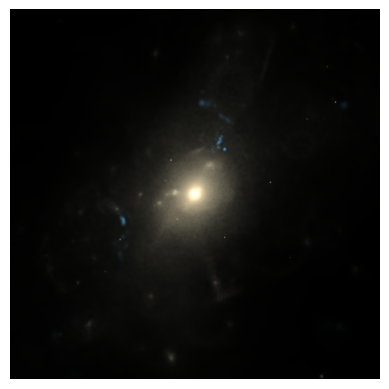

In [1]:
import pest
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = False

# ds = pest.FitsDataset("../data/SKIRT_synthetic_images/fits/TNG100/sdss/snapnum_099/data/broadband_454795.fits")
# ds = pest.FitsDataset("../data/SKIRT_synthetic_images/fits/TNG100/sdss/snapnum_099/data/broadband_137910.fits")
ds = pest.FitsDataset("../data/SKIRT_synthetic_images/fits/")
print("Number of FITS files:", len(ds))
image = ds[0]["image"]
print(image.shape)

image = pest.CreateNormalizedRGBColors(
    stretch=0.9,
    range=5,
    lower_limit=0.001,
    channel_combinations=[[2, 3], [1, 0], [0]],
    scalers=[0.7, 0.5, 1.3],
)(image)

plt.imshow(image.transpose(1, 2, 0))
plt.axis("off")
plt.show()

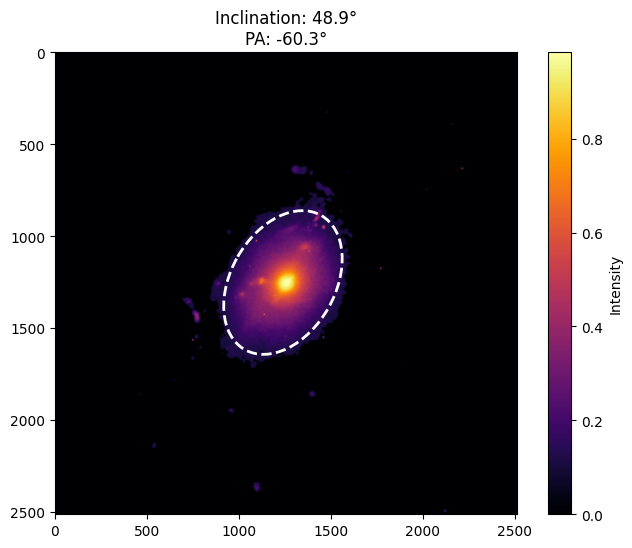

In [2]:
stats = pest.estimate_geometry_weighted(image.transpose(1, 2, 0))
pest.visualize_results(stats)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0056766264825407].


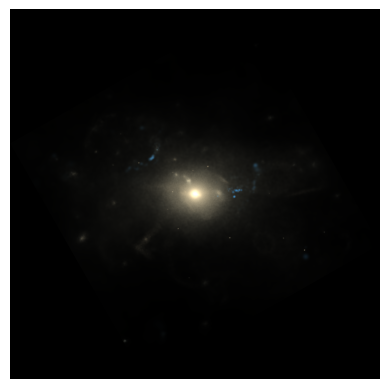

In [3]:
rotated_image = pest.AlignImageHorizontally()(image)
plt.imshow(rotated_image.transpose(1, 2, 0))
plt.axis("off")
plt.show()

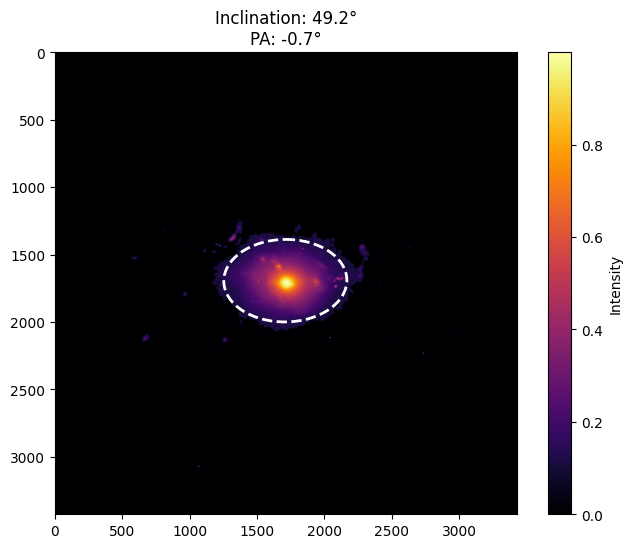

In [6]:
stats_rot = pest.estimate_geometry_weighted(rotated_image.transpose(1, 2, 0))
pest.visualize_results(stats_rot)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.008340294184719002..1.0056766264825407].


Cropped shape: (3, 1370, 1370)


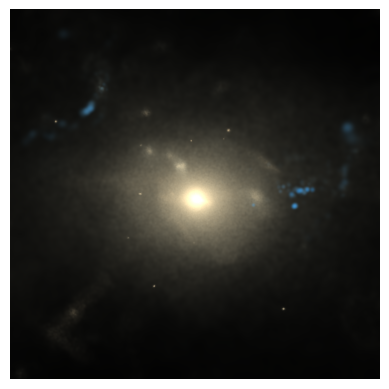

In [11]:
croped_image = pest.CropQuadratic(scale=1.5)(rotated_image)
print(f"Cropped shape: {croped_image.shape}")

plt.imshow(croped_image.transpose(1, 2, 0))
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.008574496304816924..1.0000000000030291].


Scaled shape: (3, 128, 128)


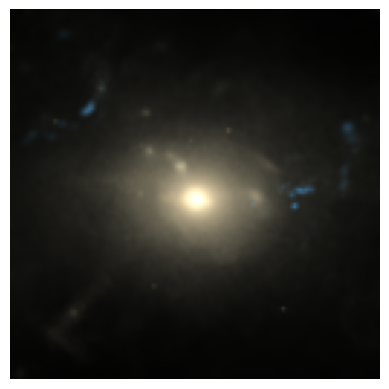

In [12]:
scaled_image = pest.ResizeImage(size=(128, 128))(croped_image)
print(f"Scaled shape: {scaled_image.shape}")

plt.imshow(scaled_image.transpose(1, 2, 0))
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.008574496304816924..1.0000000000030291].


Canonicalized shape: (3, 128, 128)


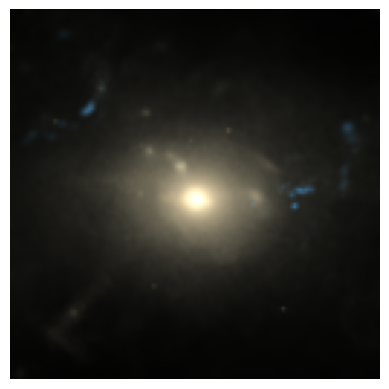

In [14]:
canonicalized_image = pest.ReflectionalInvariance()(scaled_image)
print(f"Canonicalized shape: {canonicalized_image.shape}")

plt.imshow(canonicalized_image.transpose(1, 2, 0))
plt.axis("off")
plt.show()